# 32 — Gated Fusion (Light & Heavy variants)

Trains a **gated multimodal fusion** model on top of the cached per-modality embeddings.

Two architectures are provided:

* **Light (`GatedFusionLight`)** — a 3-way Gated Multimodal Unit (Arevalo et al., 2017): each modality is projected to a common dim, a small gating network produces one *soft* per-modality weight per sample, and the gated sum is classified. Inexpensive and highly interpretable (one scalar gate per modality).
* **Heavy (`GatedFusionHeavy`)** — a 1- or 2-layer cross-modal Transformer encoder over the three modality tokens, followed by a feature-wise sigmoid gate. Captures pairwise interactions (e.g. *"text says fine but face shows anger"*) at the cost of more parameters.

Both variants reuse the same backbones as the late / intermediate fusion notebooks, controlled by `COMBO` below:

| `COMBO` | Text | Audio | Face |
|---------|------|-------|------|
| `"heavy"` | `bert-base-uncased` | `facebook/wav2vec2-base` | `vit_b_16` |
| `"light"` | `distilbert-base-uncased` | `ntu-spml/distilhubert` | `mobilenet_v3_small` |

Results are saved to `../experiments/fusion/gated/<variant>/<version>/<combo>/`.

Embeddings are loaded from the intermediate-fusion cache (`../experiments/fusion/intermediate/<version>/<combo>/cache/`) when present, so the first call after running notebook 31 is instant.


In [31]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from src.config import (
    DEVICE, VERSION,
    TRAIN_CSV, DEV_CSV, TEST_CSV,
    AUDIO_TRAIN_DIR, AUDIO_DEV_DIR, AUDIO_TEST_DIR,
    EXP_ROOT, EXP_ROOT_AUDIO, EXP_ROOT_FACE,
    FACE_MELD_CLASSES,
)
from src.data.text_preprocessing import load_split, build_label_map
from src.data.audio_preprocessing import load_audio_split
from src.data.face_dataset import load_face_metadata
from src.training.utils import slugify
from src.evaluation.gated_fusion import run_gated_fusion

# ──────────────────────────────────────────────────────────────────────────────
# Choose backbone combo (heavy/light) and gating variant (light/heavy).
# ──────────────────────────────────────────────────────────────────────────────
COMBO   = 'light'    # 'heavy' | 'light'  — chooses backbones
VARIANT = 'heavy'    # 'light' | 'heavy'  — chooses gating architecture

COMBO_MODELS = {
    'heavy': {
        'text':  'bert-base-uncased',
        'audio': 'facebook/wav2vec2-base',
        'face':  'vit_b_16',
    },
    'light': {
        'text':  'distilbert-base-uncased',
        'audio': 'ntu-spml/distilhubert',
        'face':  'mobilenet_v3_small',
    },
}

selected = COMBO_MODELS[COMBO]
print(f'Backbone combo : {COMBO}')
print(f'Gating variant : {VARIANT}')
print(f'Text   : {selected["text"]}')
print(f'Audio  : {selected["audio"]}')
print(f'Face   : {selected["face"]}')
print(f'Device : {DEVICE}')


Backbone combo : light
Gating variant : heavy
Text   : distilbert-base-uncased
Audio  : ntu-spml/distilhubert
Face   : mobilenet_v3_small
Device : cuda


## 1 — Load data


In [32]:
train_text_df = load_split(TRAIN_CSV)
label2id, id2label = build_label_map(train_text_df)
print('Label map:', label2id)

train_audio_df = load_audio_split(TRAIN_CSV, AUDIO_TRAIN_DIR, label2id=label2id)
dev_audio_df   = load_audio_split(DEV_CSV,   AUDIO_DEV_DIR,   label2id=label2id)
test_audio_df  = load_audio_split(TEST_CSV,  AUDIO_TEST_DIR,  label2id=label2id)

train_face_df = load_face_metadata('train')
dev_face_df   = load_face_metadata('dev')
test_face_df  = load_face_metadata('test')

print(f'Audio  — train: {len(train_audio_df)}, dev: {len(dev_audio_df)}, test: {len(test_audio_df)}')
print(f'Face   — train: {len(train_face_df)}, dev: {len(dev_face_df)}, test: {len(test_face_df)}')


Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Audio  — train: 9988, dev: 1108, test: 2610
Face   — train: 47800, dev: 5324, test: 12117


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\src\data\face_dataset.py:112: DtypeWarning: Columns (0: total_frames, 1: frame_idx, 2: pred_prob) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(meta_path)


## 2 — Resolve unimodal run directories


In [33]:
def resolve_run_dir(exp_root, model_name):
    d = os.path.join(exp_root, VERSION, slugify(model_name))
    metrics_path = os.path.join(d, 'eval_metrics.json')
    if not os.path.exists(metrics_path):
        train_path = os.path.join(d, 'train_metrics.json')
        if not os.path.exists(train_path):
            raise FileNotFoundError(f'No metrics found in {d!r}. Run training first.')
        f1 = json.load(open(train_path)).get('best_dev_macro_f1', '?')
        print(f'  {model_name:40s}  best_dev_macro_f1={f1}')
    else:
        f1 = json.load(open(metrics_path)).get('macro_f1', '?')
        print(f'  {model_name:40s}  test_macro_f1={f1}')
    return d

text_run_dir  = resolve_run_dir(EXP_ROOT,       selected['text'])
audio_run_dir = resolve_run_dir(EXP_ROOT_AUDIO, selected['audio'])
face_run_dir  = resolve_run_dir(EXP_ROOT_FACE,  selected['face'])


  distilbert-base-uncased                   test_macro_f1=0.41227390896790744
  ntu-spml/distilhubert                     test_macro_f1=0.22261778315512873
  mobilenet_v3_small                        test_macro_f1=0.182575


## 3 — Train gated fusion

Cached embeddings from `experiments/fusion/intermediate/<v>/<combo>/cache/` are reused if present (run notebook 31 first to produce them).


In [34]:
OUTPUT_DIR = f'../experiments/fusion/gated/{VARIANT}/{VERSION}/{COMBO}'
# Reuse the embedding cache produced by notebook 31 (so we don't re-extract).
INTER_CACHE_DIR = f'../experiments/fusion/intermediate/{VERSION}/{COMBO}/cache'
CACHE_DIR = INTER_CACHE_DIR if os.path.isdir(INTER_CACHE_DIR) else None

print(f'Output → {OUTPUT_DIR}')
print(f'Cache  → {CACHE_DIR or "(will be created in OUTPUT_DIR/cache)"}')

results = run_gated_fusion(
    text_run_dir  = text_run_dir,
    audio_run_dir = audio_run_dir,
    face_run_dir  = face_run_dir,

    train_csv_path = TRAIN_CSV,
    dev_csv_path   = DEV_CSV,
    test_csv_path  = TEST_CSV,

    train_audio_df = train_audio_df,
    dev_audio_df   = dev_audio_df,
    test_audio_df  = test_audio_df,

    train_face_df  = train_face_df,
    dev_face_df    = dev_face_df,
    test_face_df   = test_face_df,

    variant = VARIANT,

    cache_dir  = CACHE_DIR,
    output_dir = OUTPUT_DIR,
    device     = DEVICE,
)


Output → ../experiments/fusion/gated/heavy/v1/light
Cache  → ../experiments/fusion/intermediate/v1/light/cache
  Gated Fusion (HEAVY) — embedding extraction
  Loading cache: text_train
  Loading cache: text_dev
  Loading cache: text_test
  Loading cache: audio_train
  Loading cache: audio_dev
  Loading cache: audio_test
  Loading cache: face_train
  Loading cache: face_dev
  Loading cache: face_test

  Embedding dims : {'text': 768, 'audio': 256, 'face': 1024}
  Train utterances: 9783   Dev: 1091   Test: 2481

  Gated Fusion (heavy) params: 1,850,119


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  [Epoch 001/80]  train_loss=1.1234  dev_loss=1.6898  dev_macro_f1=0.4407  (best=0.4407)
  [Epoch 005/80]  train_loss=0.6195  dev_loss=1.8551  dev_macro_f1=0.4424  (best=0.4475)
  [Epoch 010/80]  train_loss=0.5511  dev_loss=1.9206  dev_macro_f1=0.4375  (best=0.4475)
  [Epoch 015/80]  train_loss=0.5190  dev_loss=2.0152  dev_macro_f1=0.4110  (best=0.4475)
  Early stop @ epoch 15 (no improvement for 12 epochs)

  Best dev macro-F1: 0.4475
  Training time: 0.3 min

  Evaluating on test set …
  Accuracy    : 0.5607
  Macro F1    : 0.4090
  Weighted F1 : 0.5669

  Modality ablation on test set …
    full            macro_f1=0.4090  acc=0.5607
    no_text         macro_f1=0.2226  acc=0.4337
    text_only       macro_f1=0.4153  acc=0.5623
    no_audio        macro_f1=0.4174  acc=0.5711
    audio_only      macro_f1=0.2152  acc=0.4248
    no_face         macro_f1=0.4147  acc=0.5655
    face_only       macro_f1=0.1318  acc=0.2044

  Artefacts saved to  ../experiments/fusion/gated/heavy/v1/light


## 4 — Results


In [35]:
tm = results['test_metrics']
print(f'Backbone combo : {COMBO}')
print(f'Gating variant : {VARIANT}')
print(f"Accuracy       : {tm['accuracy']:.4f}")
print(f"Macro F1       : {tm['macro_f1']:.4f}")
print(f"Weighted F1    : {tm['weighted_f1']:.4f}")
print(f"Utterances     : {tm['num_utterances']}")
print(f"Trainable params : {results['num_params']:,}")
print(f"Training time    : {results['training_time_s']/60:.2f} min")


Backbone combo : light
Gating variant : heavy
Accuracy       : 0.5607
Macro F1       : 0.4090
Weighted F1    : 0.5669
Utterances     : 2481
Trainable params : 1,850,119
Training time    : 0.26 min


## 5 — Per-class breakdown


In [36]:
report = tm['report']
rows = []
for cls in FACE_MELD_CLASSES:
    if cls in report:
        r = report[cls]
        rows.append({'class': cls,
                     'precision': round(r['precision'], 4),
                     'recall':    round(r['recall'],    4),
                     'f1-score':  round(r['f1-score'],  4),
                     'support':   int(r['support'])})
pd.DataFrame(rows)


,class,precision,recall,f1-score,support
0,Anger,0.3893,0.3323,0.3586,328
1,Disgust,0.2647,0.2727,0.2687,66
2,Fear,0.1068,0.2245,0.1447,49
3,Happiness,0.5610,0.5321,0.5462,389
4,Neutral,0.7369,0.6986,0.7172,1191
5,Sadness,0.2930,0.3298,0.3103,191
6,Surprise,0.4763,0.5655,0.5171,267


## 6 — Training curves


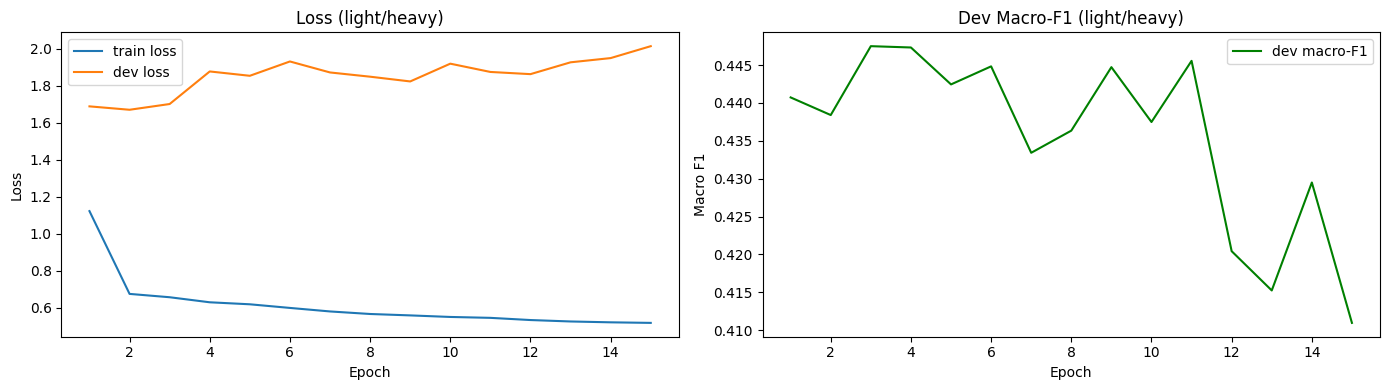

In [37]:
history = pd.DataFrame(results['history'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['epoch'], history['train_loss'], label='train loss')
ax1.plot(history['epoch'], history['dev_loss'],   label='dev loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'Loss ({COMBO}/{VARIANT})'); ax1.legend()

ax2.plot(history['epoch'], history['dev_macro_f1'], color='green', label='dev macro-F1')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
ax2.set_title(f'Dev Macro-F1 ({COMBO}/{VARIANT})'); ax2.legend()
plt.tight_layout(); plt.show()


## 7 — Gating explainability

The gates show *how much each modality contributes* on average and per emotion class. For the **light** variant the gates are interpretable softmax weights over modalities (sum to 1). For the **heavy** variant the gates are per-feature sigmoids in `[0, 1]`; we report their per-token mean.


Overall mean gate value per modality:
  text    0.472
  audio   0.476
  face    0.470


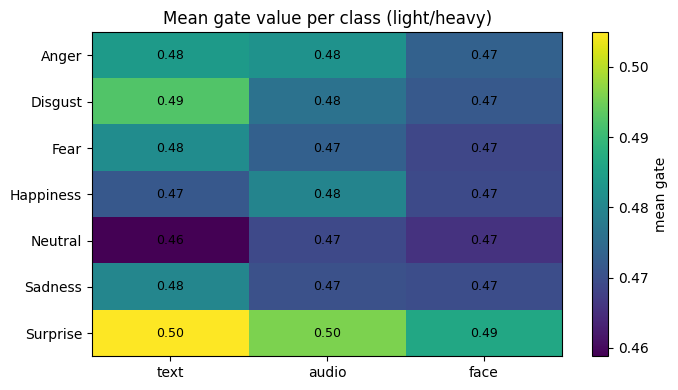

In [38]:
gate_stats = results['gate_stats']

if not gate_stats:
    print('No gates available for this variant.')
else:
    modalities    = gate_stats['modalities']
    mean_overall  = gate_stats['mean_overall']
    mean_by_class = gate_stats['mean_by_class']  # (C, M)

    print('Overall mean gate value per modality:')
    for m, v in zip(modalities, mean_overall):
        print(f'  {m:7s} {v:.3f}')

    # ── Per-class gate heatmap
    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(mean_by_class, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(modalities)))
    ax.set_xticklabels(modalities)
    ax.set_yticks(range(len(FACE_MELD_CLASSES)))
    ax.set_yticklabels(FACE_MELD_CLASSES)
    for c in range(mean_by_class.shape[0]):
        for m in range(mean_by_class.shape[1]):
            ax.text(m, c, f'{mean_by_class[c, m]:.2f}',
                    ha='center', va='center',
                    color='white' if mean_by_class[c, m] < mean_by_class.max() * 0.6 else 'black',
                    fontsize=9)
    ax.set_title(f'Mean gate value per class ({COMBO}/{VARIANT})')
    plt.colorbar(im, ax=ax, label='mean gate')
    plt.tight_layout(); plt.show()


## 8 — Modality ablation

Zeros out modalities at inference to quantify their contribution.


In [39]:
ablation = results['ablation']
ab_rows = []
for name, m in ablation.items():
    ab_rows.append({
        'configuration':  name,
        'accuracy':       round(m['accuracy'], 4),
        'macro_f1':       round(m['macro_f1'], 4),
        'weighted_f1':    round(m['weighted_f1'], 4),
        'Δ macro_f1':     round(m['macro_f1'] - ablation['full']['macro_f1'], 4),
    })
pd.DataFrame(ab_rows)


,configuration,accuracy,macro_f1,weighted_f1,Δ macro_f1
0,full,0.5607,0.4090,0.5669,0.0000
1,no_text,0.4337,0.2226,0.4073,-0.1864
2,text_only,0.5623,0.4153,0.5776,0.0063
3,no_audio,0.5711,0.4174,0.5829,0.0084
4,audio_only,0.4248,0.2152,0.4020,-0.1938
5,no_face,0.5655,0.4147,0.5709,0.0057
6,face_only,0.2044,0.1318,0.2235,-0.2771


## 9 — Confusion matrix


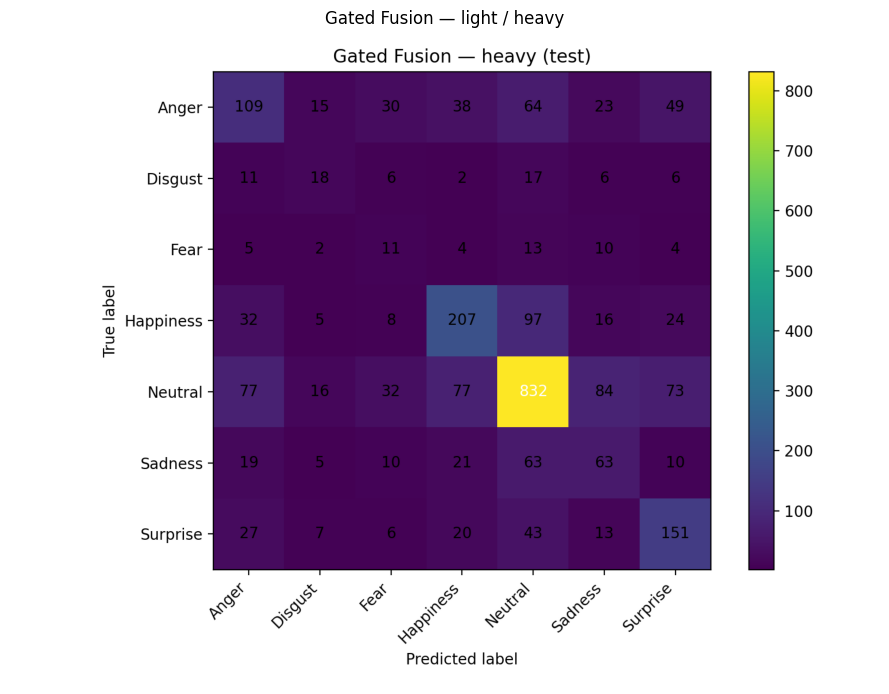

In [40]:
img_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_test.png')
if os.path.exists(img_path):
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.imshow(mpimg.imread(img_path))
    ax.axis('off')
    ax.set_title(f'Gated Fusion — {COMBO} / {VARIANT}')
    plt.tight_layout(); plt.show()
